# Participação no ENEM: 2024 e 2025

A comparação descreve os registros publicados em cada edição. Presença completa exige código 1 nas duas áreas do dia; eliminações, situações mistas e dados incompletos permanecem separados. Não há acompanhamento das mesmas pessoas entre anos nem inferência de causas.

Este notebook lê somente agregados e a validação existente. Para atualizar os cálculos de 2024, execute antes `notebooks/08_participacao_2024.ipynb`.


In [1]:
from pathlib import Path
import sys, json
raiz = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/participacao.py').exists())
if str(raiz) not in sys.path: sys.path.insert(0, str(raiz))
import pandas as pd
from IPython.display import display, Image, Markdown
from src.participacao_comparacao_graficos import gerar_comparacao
from src.participacao_graficos import numero, porcentagem
from src.desempenho_execucao import hash_arquivo
dias = pd.read_csv(raiz/'analitica/participacao_2024_2025_dias.csv')
transicoes = pd.read_csv(raiz/'analitica/participacao_2024_2025_transicoes.csv')
resumos = pd.read_csv(raiz/'analitica/participacao_2024_2025_resumo.csv')
comparacao = pd.read_csv(raiz/'analitica/participacao_2024_2025_comparacao.csv')
from src.participacao_comparacao import comparar_participacao
resultados = {}
for ano in (2024,2025):
    report = json.loads((raiz/f'reports/validacao_participacao_{ano}.json').read_text(encoding='utf-8'))
    resultados[ano] = report['resultado']
    for nome,h in report['hashes_csv'].items():
        if hash_arquivo(raiz/'analitica'/nome) != h: raise ValueError(f'Agregado alterado: {nome}')
    for tipo, tabela in [('dias',dias),('transicoes',transicoes),('resumo',resumos)]:
        original = pd.read_csv(raiz/f'analitica/participacao_{ano}_{tipo}.csv')
        pd.testing.assert_frame_equal(tabela.loc[tabela.edicao==ano].drop(columns='edicao').reset_index(drop=True), original, check_dtype=False)
pd.testing.assert_frame_equal(comparacao, pd.DataFrame(comparar_participacao(resultados)['comparacao']), check_dtype=False)
display(resumos[['edicao','total_base','presentes_dia1','presentes_dia2','presentes_ambos','retencao_percentual']])


,edicao,total_base,presentes_dia1,presentes_dia2,presentes_ambos,retencao_percentual
0,2024,4332944,3167955,3004981,2990093,94.385589
1,2025,4810772,3457555,3260336,3244348,93.833590


## A participação de 2024

A taxa por dia usa todos os registros divulgados em RESULTADOS 2024. O gráfico mostra as categorias observadas; a tabela mantém inclusive as categorias com contagem zero.


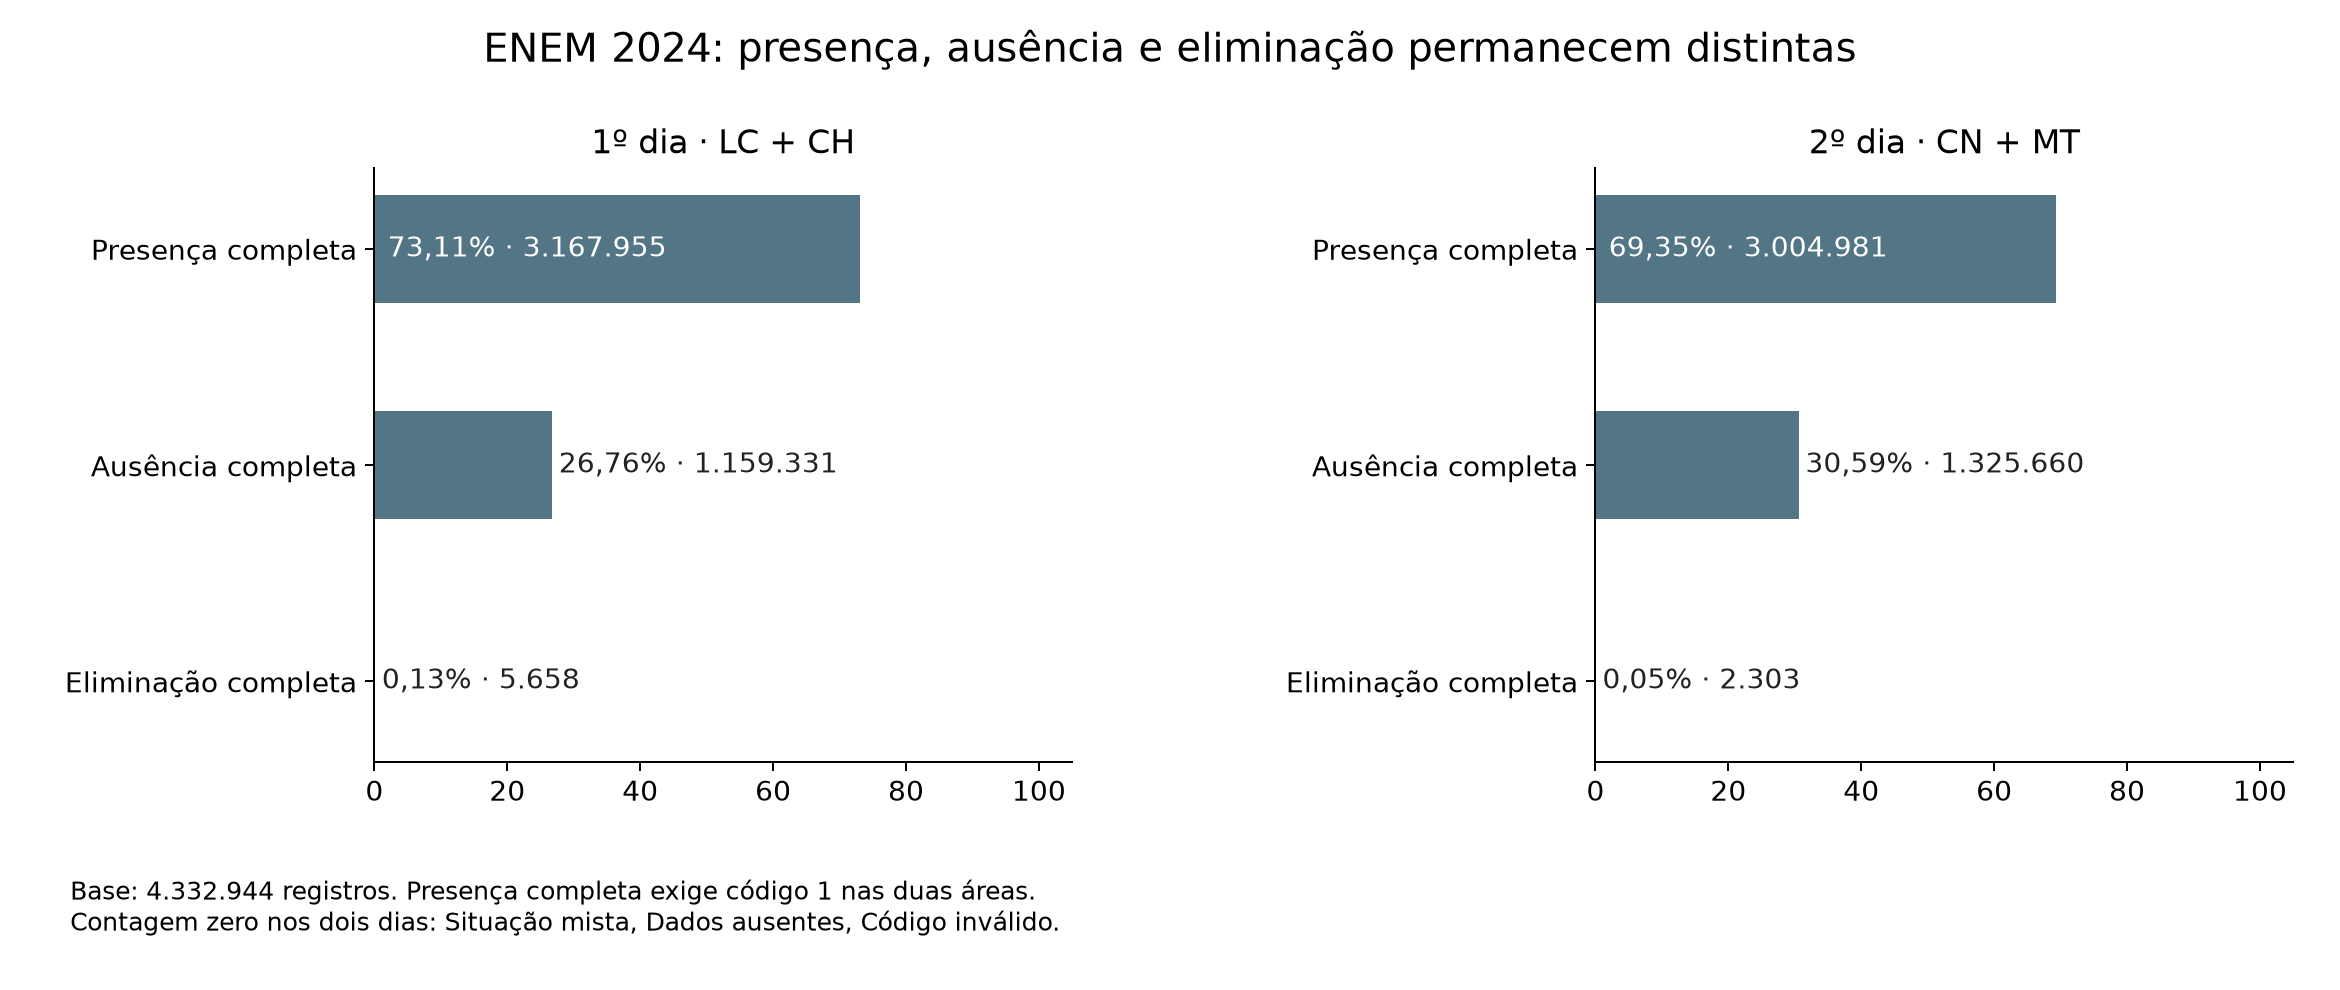

,edicao,dia,status,quantidade,percentual_base
0,2024,1,presente,3167955,73.113223
1,2024,1,ausente,1159331,26.756196
2,2024,1,eliminado,5658,0.130581
3,2024,1,misto,0,0.000000
4,2024,1,dados_ausentes,0,0.000000
5,2024,1,codigo_invalido,0,0.000000
6,2024,2,presente,3004981,69.351946
7,2024,2,ausente,1325660,30.594903
8,2024,2,eliminado,2303,0.053151
9,2024,2,misto,0,0.000000


In [2]:
arquivos = gerar_comparacao(dias, comparacao, raiz/'apresentacao/graficos')
display(Image(filename=str(arquivos[1])))
display(dias.loc[dias.edicao==2024].reset_index(drop=True))


## O que muda em 2025

As taxas são calculadas separadamente por edição. A permanência usa presentes nos dois dias divididos pelos presentes no primeiro; não tem o mesmo denominador da taxa diária. Diferenças em pontos percentuais são 2025 menos 2024.


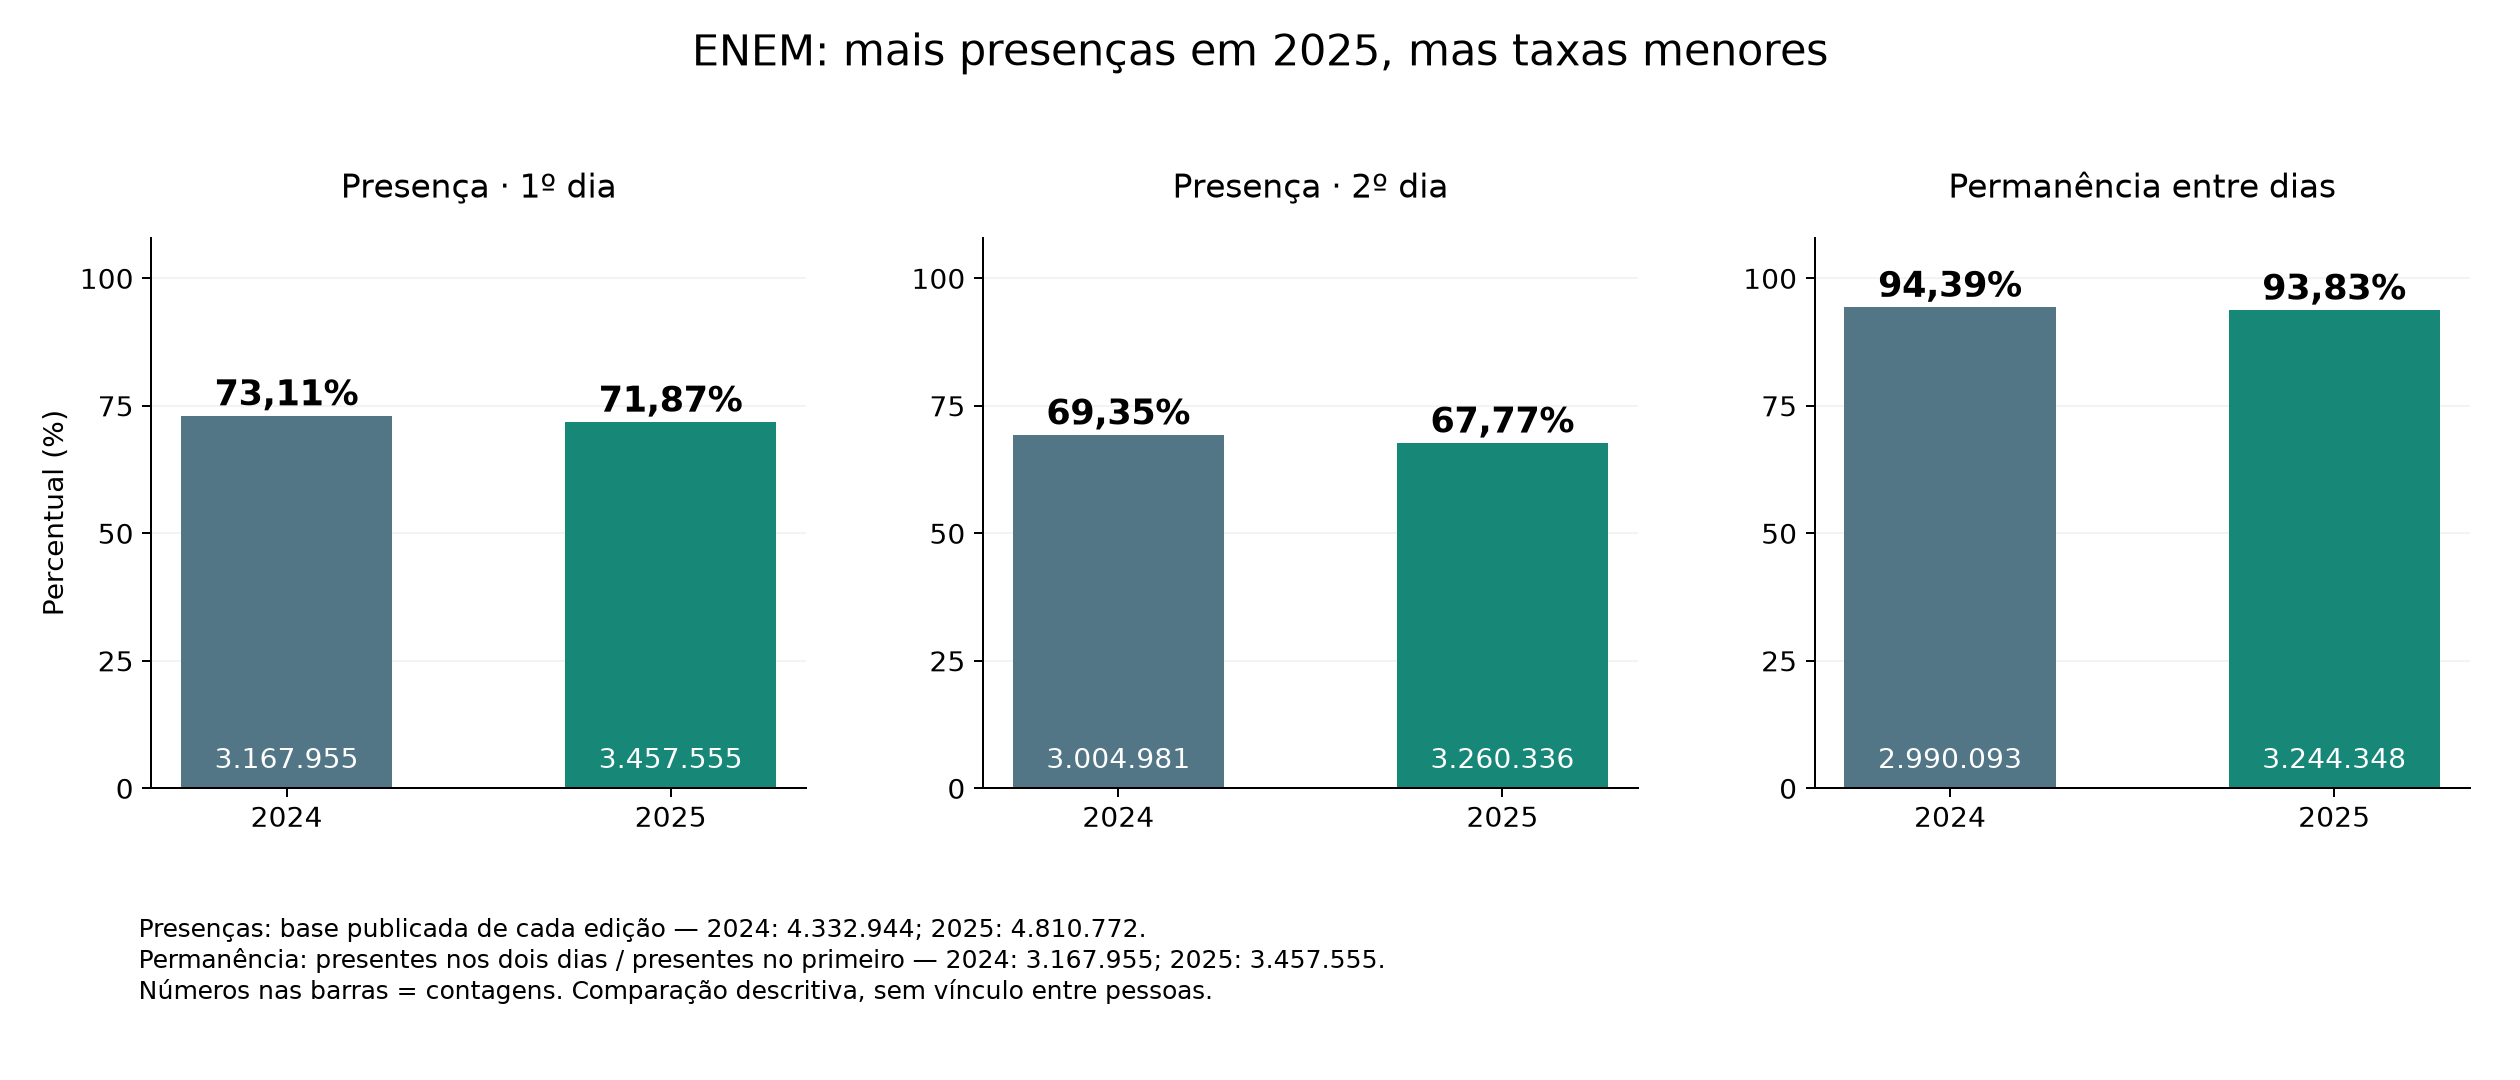

,indicador,contagem_2024,denominador_2024,taxa_2024,contagem_2025,denominador_2025,taxa_2025,diferenca_contagem_2025_menos_2024,diferenca_pp_2025_menos_2024
0,presenca_dia1,3167955,4332944,73.113223,3457555,4810772,71.871105,289600,-1.242118
1,presenca_dia2,3004981,4332944,69.351946,3260336,4810772,67.771576,255355,-1.580370
2,presenca_ambos,2990093,4332944,69.008346,3244348,4810772,67.439238,254255,-1.569108
3,retencao,2990093,3167955,94.385589,3244348,3457555,93.833590,254255,-0.551999


**presenca_dia1:** 73,11% em 2024 → 71,87% em 2025; diferença de -1,24 p.p.

**presenca_dia2:** 69,35% em 2024 → 67,77% em 2025; diferença de -1,58 p.p.

**presenca_ambos:** 69,01% em 2024 → 67,44% em 2025; diferença de -1,57 p.p.

**retencao:** 94,39% em 2024 → 93,83% em 2025; diferença de -0,55 p.p.

In [3]:
display(Image(filename=str(arquivos[0])))
display(comparacao)
for _, linha in comparacao.iterrows():
    delta = f"{linha.diferenca_pp_2025_menos_2024:+.2f}".replace('.', ',')
    display(Markdown(f"**{linha.indicador}:** {porcentagem(linha.taxa_2024)} em 2024 → {porcentagem(linha.taxa_2025)} em 2025; diferença de {delta} p.p."))


## Transições e limites

Presente → ausente é a ausência estrita após o primeiro dia. A diferença líquida entre dias também incorpora entradas e outras saídas, como eliminações; os dois números não são equivalentes. Mudanças de volume e perfil dos inscritos podem afetar as taxas. A comparação não isola causas nem representa uma amostra pareada.


In [4]:
colunas = ['edicao','somente_primeiro_ausente_segundo','somente_segundo_ausente_primeiro','ausentes_ambos','demais_situacoes','diferenca_liquida_dia2_menos_dia1']
display(resumos[colunas])
display(transicoes.loc[transicoes.quantidade>0].reset_index(drop=True))


,edicao,somente_primeiro_ausente_segundo,somente_segundo_ausente_primeiro,ausentes_ambos,demais_situacoes,diferenca_liquida_dia2_menos_dia1
0,2024,175619,14004,1145272,7956,-162974
1,2025,211292,15146,1332913,7073,-197219


,edicao,dia1,dia2,quantidade,percentual_base,denominador_origem,percentual_origem
0,2024,presente,presente,2990093,69.008346,3167955,94.385589
1,2024,presente,ausente,175619,4.053110,3167955,5.543608
2,2024,presente,eliminado,2243,0.051766,3167955,0.070803
3,2024,ausente,presente,14004,0.323198,1159331,1.207938
4,2024,ausente,ausente,1145272,26.431729,1159331,98.787318
5,2024,ausente,eliminado,55,0.001269,1159331,0.004744
6,2024,eliminado,presente,884,0.020402,5658,15.623895
7,2024,eliminado,ausente,4769,0.110064,5658,84.287734
8,2024,eliminado,eliminado,5,0.000115,5658,0.088370
9,2025,presente,presente,3244348,67.439238,3457555,93.833590


Os outros cinco temas de 2024 permanecem fora deste incremento. Perfil econômico e notas de 2024–2025 continuam independentes. Fontes: agregados `analitica/participacao_*`; contrato `docs/contrato_participacao_2024_2025.md`; cálculo e controles no notebook 08.
